<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/Methylation_practice/methylation_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methylation analysis tutorial


##Part1. Data and R package download

In [2]:
import gdown

file_id = "1EXHskqkd61fPfsSHREPuuFZODTz4sSQg"
output = "/content/methylation.tar" # 저장 위치 및 저장할 파일 이름
gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1EXHskqkd61fPfsSHREPuuFZODTz4sSQg
From (redirected): https://drive.google.com/uc?id=1EXHskqkd61fPfsSHREPuuFZODTz4sSQg&confirm=t&uuid=d63c3eba-66c2-4e52-8327-80434789c451
To: /content/methylation.tar
100%|██████████| 2.59G/2.59G [00:26<00:00, 96.3MB/s]


'/content/methylation.tar'

In [3]:
# tar 파일 압축 해제

!tar -xf /content/methylation.tar

In [4]:
# R 사용환경 세팅

!pip install -q rpy2
%load_ext rpy2.ipython

In [5]:
# R 라이브러리 path 지정
%%R
.libPaths("/content/content/drive/MyDrive/bomun_hands_on_exercise/Methylation_Practice/R_libs")
.libPaths()

[1] "/content/content/drive/MyDrive/bomun_hands_on_exercise/Methylation_Practice/R_libs"
[2] "/usr/local/lib/R/site-library"                                                     
[3] "/usr/lib/R/site-library"                                                           
[4] "/usr/lib/R/library"                                                                


## Part 2. Library Import and Quality Control

In [6]:
%%R
suppressPackageStartupMessages({
  library(minfi)
  library(dplyr)
  library(tidyverse)
})

### 2-1. IDAT 파일 불러오기

In [7]:
# Working directory 설정
%%R

setwd('/content/content/drive/MyDrive/bomun_hands_on_exercise/Methylation_Practice')
getwd()

[1] "/content/content/drive/MyDrive/bomun_hands_on_exercise/Methylation_Practice"


In [8]:
# Sample 정보 + idat 파일 정보 담은 sample sheet 불러오기
%%R
target <- read.metharray.sheet("./IDAT", pattern="SampleSheet.csv")

[1] "./IDAT/SampleSheet.csv"


[read.metharray.sheet] Found the following CSV files:
In addition: Warning messages:
1: In FUN(X[[i]], ...) :
  Could not infer array name for file: ./IDAT/SampleSheet.csv
2: In FUN(X[[i]], ...) :
  Could not infer slide name for file: ./IDAT/SampleSheet.csv


In [9]:
%%R
head(target)

         ind  age sex      cohort    sample
1 GSM6927590 64.0   F replication healthy73
2 GSM6927595 65.7   F replication healthy78
3 GSM6927596 58.2   F replication healthy79
4 GSM6927597 40.6   F replication healthy80
5 GSM6927598 36.0   F replication healthy81
6 GSM6927599 47.4   F replication healthy82
                                    Basename   group
1 ./850k_IDAT/GSM6927590_200875800086_R01C01 healthy
2 ./850k_IDAT/GSM6927595_200925700056_R07C01 healthy
3 ./850k_IDAT/GSM6927596_200925700056_R02C01 healthy
4 ./850k_IDAT/GSM6927597_200925700057_R03C01 healthy
5 ./850k_IDAT/GSM6927598_200925700057_R05C01 healthy
6 ./850k_IDAT/GSM6927599_200925700101_R03C01 healthy


In [10]:
# EPIC array data 불러오기 (1~2분 정도 소요)
%%R

rgSet <- read.metharray.exp(targets=target)
rgSet

class: RGChannelSet 
dim: 1052641 20 
metadata(0):
assays(2): Green Red
rownames(1052641): 1600101 1600111 ... 99810990 99810992
rowData names(0):
colnames(20): GSM6927590_200875800086_R01C01
  GSM6927595_200925700056_R07C01 ... GSM6927634_200925700035_R08C01
  GSM6927637_200925700056_R06C01
colData names(8): ind age ... group filenames
Annotation
  array: IlluminaHumanMethylationEPIC
  annotation: ilm10b4.hg19


In [11]:
%%R
# rgSet sample name 실제 샘플명으로 변경
sampleNames(rgSet)
sampleNames(rgSet) <- target$sample


In [12]:
# Phenotype data 저장
%%R
phenoData <- pData(rgSet)

### 2-2. Sample QC

In [13]:
# Red green data -> Methyl and UnMethyl dataset
%%R

MSet <- preprocessRaw(rgSet)

Loading required package: IlluminaHumanMethylationEPICmanifest


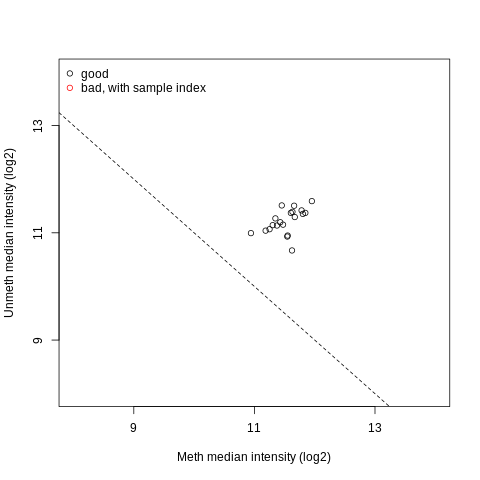

In [14]:
%%R
# check sample intensity
# if log2(median intensity Meth + Unmeth signal per sample) < 10.5 -> bad quality sample

qc <- getQC(MSet)


plotQC(qc)

In [15]:
%%R

RSet <- ratioConvert(MSet, what = "both", keepCN = TRUE)
GRset <- mapToGenome(RSet)

Loading required package: IlluminaHumanMethylationEPICanno.ilm10b4.hg19


In [16]:
# CN value 이용한 성별 추정
%%R

sex <- getSex(GRset, cutoff = -2) %>% as.data.frame()
sex$sample <- rownames(sex)

In [17]:
%%R

real_sex <- phenoData[,c('sample', 'sex')]

colnames(real_sex)[2] <- "Real Sex"



In [18]:
%%R

sex_infer <- merge(sex, real_sex)

sex_infer


DataFrame with 20 rows and 5 columns
         sample      xMed      yMed predictedSex    Real Sex
    <character> <numeric> <numeric>  <character> <character>
1     healthy73   12.5720   9.13443            F           F
2     healthy78   12.9708   9.98157            F           F
3     healthy79   12.8764   9.77643            F           F
4     healthy80   12.6623   9.64205            F           F
5     healthy81   12.9476   9.91886            F           F
...         ...       ...       ...          ...         ...
16      Obese83   12.2735  12.62205            M           M
17      Obese84   12.2650  12.60825            M           M
18      Obese87   12.8097   9.67243            F           F
19      Obese93   12.6959   9.93664            F           F
20      Obese96   13.1094   9.97154            F           F


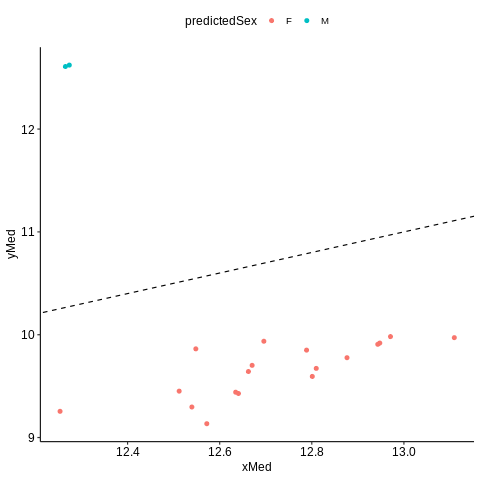

In [19]:
# Sex inference plotting
%%R
library(ggpubr)
ggplot(data=sex, aes(x=xMed, y= yMed, colour = predictedSex)) +
  geom_point() + theme_pubr()+
  geom_abline(intercept = -2, slope = 1, linetype = "dashed", color = "black")

In [20]:
# Probe p-value detection (negative control probe 대비 intensity가 유의하게 큰지 test!)
%%R

detP <- detectionP(rgSet)

detP[1:5,1:5]


               healthy73     healthy78 healthy79     healthy80     healthy81
cg18478105  0.000000e+00  0.000000e+00         0  0.000000e+00  0.000000e+00
cg09835024  0.000000e+00  0.000000e+00         0  0.000000e+00  0.000000e+00
cg14361672  0.000000e+00  0.000000e+00         0  0.000000e+00  0.000000e+00
cg01763666  0.000000e+00  0.000000e+00         0  0.000000e+00  0.000000e+00
cg12950382 1.898476e-228 2.366149e-165         0 2.561736e-125 3.930693e-203


In [22]:
# Mean detection p-value > 0.05 인 샘플 필터링
%%R

out_p_per_sample <- colMeans(detP) %>% as.data.frame()
colnames(out_p_per_sample) <- "mean_p"

out_p_per_sample

                mean_p
healthy73 0.0001410816
healthy78 0.0002544315
healthy79 0.0002348800
healthy80 0.0002461906
healthy81 0.0002848556
healthy82 0.0002226710
healthy84 0.0002434056
healthy87 0.0002456247
healthy92 0.0001694041
healthy96 0.0001474167
Obese75   0.0002614994
Obese78   0.0008012632
Obese80   0.0002703243
Obese81   0.0004347968
Obese82   0.0002307750
Obese83   0.0001385793
Obese84   0.0001259572
Obese87   0.0001014455
Obese93   0.0004395651
Obese96   0.0002600858


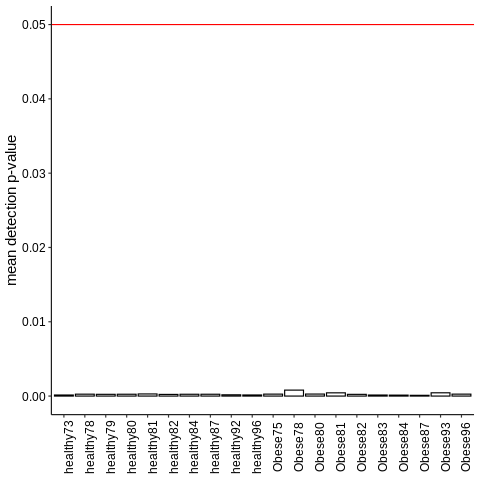

In [23]:
%%R

ggplot(out_p_per_sample, aes(x=rownames(out_p_per_sample),y=mean_p)) +
  geom_col(fill = NA, color = 'black') + theme_pubr() +
  xlab(NULL) + ylab("mean detection p-value")+
  theme(axis.text.x = element_text(angle = 90), axis.title.y = element_text(size = 15)) +
  geom_hline(yintercept = 0.05, color='red')

## 3. Normalization (Quantile)

In [24]:
%%R

mSetSq <- preprocessQuantile(rgSet)

[preprocessQuantile] Mapping to genome.
[preprocessQuantile] Fixing outliers.
[preprocessQuantile] Quantile normalizing.


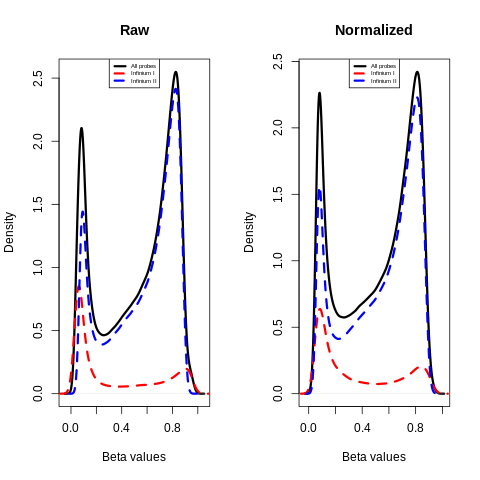

In [25]:
# before norm / after norm beta value distribution
%%R

par(mfrow=c(1,2))

plotBetasByType(MSet[,2],main="Raw", cex.legend = 0.5)

typeI <- getProbeInfo(MSet, type = "I")[, c("Name","nCpG")]
typeII <- getProbeInfo(MSet, type = "II")[, c("Name","nCpG")]
probeTypes <- rbind(typeI, typeII)
probeTypes$Type <- rep(x = c("I", "II"), times = c(nrow(typeI), nrow(typeII)))

# Now plot the distributions of the normalized data for sample 2
plotBetasByType(getBeta(mSetSq)[,2], probeTypes = probeTypes, main="Normalized", cex.legend = 0.5)


## 4. Probe filtering

In [26]:
#1. 1개 샘플 이상에서 p-value > 0.01 인 Probe 제거
%%R

detP <- detP[match(featureNames(mSetSq), rownames(detP)), ]
keep <- rowSums(detP < 0.01) == ncol(mSetSq)
mSetSqFlt <- mSetSq[keep,]

In [27]:
#2. SNP region Probe 제거
%%R

mSetSqFlt <- dropLociWithSnps(mSetSqFlt,snps = c("CpG", "SBE"))

In [28]:
#3. Sex chromosome Probe 제거

%%R

annotation <- getAnnotation(mSetSqFlt)
sex_chr_probes <- rownames(annotation)[annotation$chr %in% c("chrX", "chrY")]

keep_probes <- !rownames(mSetSqFlt) %in% sex_chr_probes

mSet_filtered <- mSetSqFlt[keep_probes, ]

## 5. PCA analysis

In [29]:
# beta, M-value extract
%%R

beta_filtered <- getBeta(mSet_filtered)
m_filtered <- getM(mSet_filtered)

In [30]:
%%R

pca_result <- prcomp(t(m_filtered), center = TRUE, scale. = F)
var_explained <- summary(pca_result)$importance[2,]

In [31]:
%%R

identical(rownames(pca_result$x), phenoData$sample)

[1] TRUE


In [32]:
%%R

pca_df <- data.frame(
  PC1 = pca_result$x[,1],
  PC2 = pca_result$x[,2],
  Group = phenoData$group, # 그룹 정보
  Age= phenoData$age
)

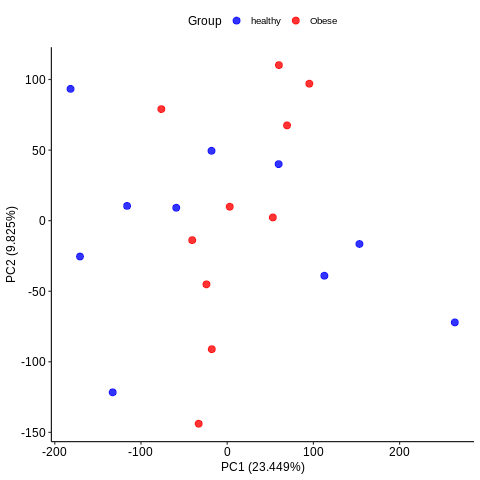

In [33]:
%%R

ggplot(pca_df, aes(x = PC1, y = PC2, color = Group)) +
  scale_color_manual(values = c("blue", "red")) +
  geom_point(size = 3, alpha = 0.8) +
  theme_pubr() +
  xlab(label = paste0('PC1 (',var_explained[1]*100, '%)')) +
  ylab(label = paste0('PC2 (',var_explained[2]*100, '%)')) +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))

In [34]:
%%R

vars <- apply(m_filtered, 1, var, na.rm = TRUE)

In [35]:
%%R

vars_sorted <- sort(vars, decreasing = TRUE)

# 분산이 큰 상위 10,000개 CpG cite로 PCA 보는게 적절?
cutoff_10000 <- vars_sorted[10000]

cutoff_10000

cg14059744 
 0.3095875 


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


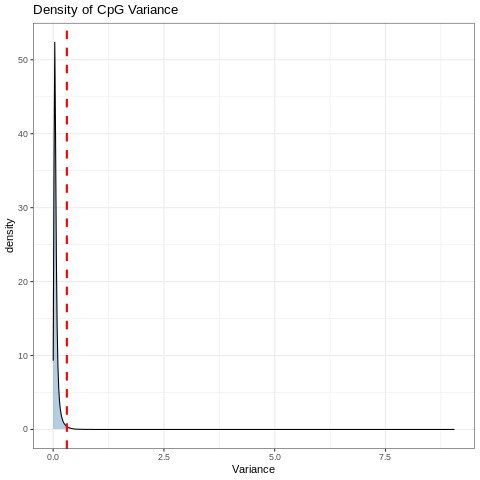

In [36]:
%%R
vars_df <- data.frame(Variance = vars)

ggplot(vars_df, aes(x = Variance)) +
  geom_density(fill = "steelblue", alpha = 0.4) +
  geom_vline(xintercept = cutoff_10000,
             color = "red",
             linetype = "dashed",
             size = 1) +
  theme_bw() +
  ggtitle("Density of CpG Variance")

In [37]:
%%R

top10000 <- names(sort(vars, decreasing = TRUE))[1:10000]

m_10000 <- m_filtered[top10000, ]

pca_result <- prcomp(t(m_10000), center = TRUE, scale. = F)
var_explained <- summary(pca_result)$importance[2, ]

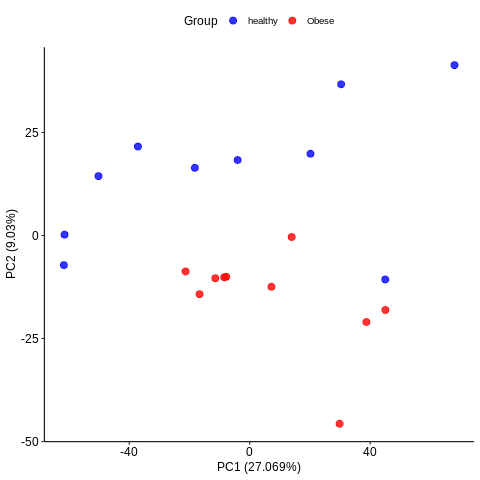

In [38]:
%%R

pca_df <- data.frame(
  PC1 = pca_result$x[,1],
  PC2 = pca_result$x[,2],
  Group = phenoData$group, # 그룹 정보
  Age= phenoData$age
)


ggplot(pca_df, aes(x = PC1, y = PC2, color = Group)) +
  scale_color_manual(values = c("blue", "red")) +
  geom_point(size = 3, alpha = 0.8) +
  theme_pubr() +
  xlab(label = paste0('PC1 (',var_explained[1]*100, '%)')) +
  ylab(label = paste0('PC2 (',var_explained[2]*100, '%)')) +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))



### 5-2. Batch correction Using SVA

In [39]:
%%R
library(sva)
library(limma)
m_filtered <- getM(mSet_filtered)

mod <- model.matrix(~as.factor(group), data=phenoData)
mod0 <- model.matrix(~1, data=phenoData)
sva.results <- sva(m_filtered[top10000,], mod, mod0)


Number of significant surrogate variables is:  3 
Iteration (out of 5 ):1  2  3  4  5  

Loading required package: mgcv
Loading required package: nlme

Attaching package: ‘nlme’

The following object is masked from ‘package:dplyr’:

    collapse

The following object is masked from ‘package:Biostrings’:

    collapse

The following object is masked from ‘package:IRanges’:

    collapse

This is mgcv 1.9-4. For overview type '?mgcv'.

Attaching package: ‘mgcv’

The following object is masked from ‘package:locfit’:

    lp

Loading required package: genefilter

Attaching package: ‘genefilter’

The following object is masked from ‘package:readr’:

    spec

The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars

The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars

Loading required package: BiocParallel

Attaching package: ‘limma’

The following object is masked from ‘package:BiocGenerics’:

    plotMA



In [40]:
%%R

sv_out <- sva.results$sv
sv_out

              [,1]         [,2]        [,3]
 [1,]  0.201712263  0.008375896 -0.01134967
 [2,]  0.003663717 -0.064459013 -0.13707126
 [3,]  0.384385787  0.007519344  0.04258052
 [4,] -0.147693268  0.016304060 -0.08410383
 [5,]  0.297672288  0.205609801  0.20270565
 [6,]  0.403979311 -0.556531383 -0.46282930
 [7,]  0.080438808  0.021094530 -0.01370988
 [8,] -0.234206928  0.165853259  0.03660864
 [9,] -0.449037861  0.072553463 -0.13806037
[10,] -0.253702718 -0.039619637 -0.15066587
[11,] -0.230370036 -0.086091773 -0.17465344
[12,] -0.179957829 -0.626225649  0.72333263
[13,]  0.061062169  0.280570177  0.16796949
[14,]  0.157195144  0.197527553  0.13020353
[15,]  0.104146672 -0.023798449 -0.05267311
[16,]  0.067121424  0.198102433  0.10187937
[17,]  0.084497750  0.126466295  0.06069623
[18,] -0.262317574 -0.089725912 -0.22374896
[19,] -0.071509340  0.022121538 -0.07051495
[20,] -0.017079780  0.164353468  0.05340457


In [45]:
%%R

correction_result <- removeBatchEffect(x = m_filtered,
                                 covariates = sva.results$sv[,1:3],
                                 design = mod)

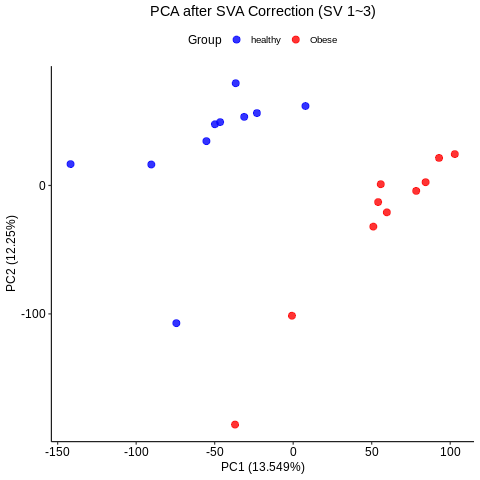

In [47]:

%%R
# batch correction

pca_res <- prcomp(t(correction_result), center = TRUE, scale. = FALSE)
var_explained <- summary(pca_res)$importance[2, 1:10]


pca_df <- data.frame(
  PC1 = pca_res$x[,1],
  PC2 = pca_res$x[,2],
  Group = phenoData$group
)

# ggplot 그리기
ggplot(pca_df, aes(x = PC1, y = PC2, color = Group)) +
  scale_color_manual(values = c("blue", "red")) +
  geom_point(size = 3, alpha = 0.8) +
  theme_pubr() +
  xlab(label = paste0('PC1 (',var_explained[1]*100, '%)')) +
  ylab(label = paste0('PC2 (',var_explained[2]*100, '%)')) +
  labs(title = "PCA after SVA Correction (SV 1~3)") +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))



## 6. Differentially methylated Probe (DMP) analysis

In [49]:
%%R

mVals <- getM(mSet_filtered)

group <- factor(target$group)

design <- model.matrix(~0+group+sv_out[,1]+sv_out[,2] + sv_out[,3], data=target)

colnames(design) <- c(levels(group),"SV1", "SV2", "SV3")

In [50]:
%%R

# fit the actual linear model to the data
fit <- lmFit(mVals, design)

In [51]:
%%R
fit

An object of class "MArrayLM"
$coefficients
              healthy     Obese        SV1         SV2         SV3
cg14817997 0.08711567 0.4705857 -0.7712632  0.16956144 -0.95156345
cg26928153 1.78257430 1.7633323 -0.1633878 -0.08121303 -0.08372747
cg16269199 0.59766140 0.6186178 -0.1155486 -0.28324762  0.07043367
cg13869341 2.06528742 2.2056623  0.5988084  0.16899273 -0.49676181
cg14008030 0.93370383 0.7639537 -0.1853350  0.09296107  0.40197299
813785 more rows ...

$rank
[1] 5

$assign
[1] 1 1 2 3 4

$qr
$qr
     healthy     Obese         SV1          SV2         SV3
1 -3.1622777  0.000000 -0.09082422  0.051639893  0.22638599
2  0.3162278 -3.162278  0.09082422 -0.051639893 -0.22638599
3  0.3162278  0.000000 -0.99171665 -0.009458655 -0.04146614
4  0.3162278  0.000000 -0.21979671 -0.997284902  0.02383803
5  0.3162278  0.000000  0.22928878  0.211812713 -0.94615594
15 more rows ...

$qraux
[1] 1.316228 1.000000 1.316727 1.031353 1.254545

$pivot
[1] 1 2 3 4 5

$tol
[1] 1e-07

$rank
[1] 5


$

In [52]:
%%R

contMatrix <- makeContrasts(Obese-healthy,
                            levels=design)
contMatrix

         Contrasts
Levels    Obese - healthy
  healthy              -1
  Obese                 1
  SV1                   0
  SV2                   0
  SV3                   0


In [54]:
# DMP analysis
%%R

fit2 <- contrasts.fit(fit, contMatrix)
# Rank genes
fit2 <- eBayes(fit2)
DMPs <- topTable(fit2, num=Inf, coef=1)

In [57]:
# DMP 기준 설정
%%R

logFC_cutoff <- 1
adj.p_cutoff <- 0.05

In [58]:
%%R

sig_DMPs <- DMPs %>%
  filter(adj.P.Val < adj.p_cutoff) %>% as.data.frame()

In [63]:
# logFC 양수 중 상위 5개
%%R

top_up <- sig_DMPs %>%
  filter(logFC > 0) %>%
  arrange(desc(logFC)) %>%
  slice(1:5) %>% rownames()

# logFC 음수 중 하위 5개
top_down <- sig_DMPs %>%
  filter(logFC < 0) %>%
  arrange(logFC) %>%
  slice(1:5) %>% rownames()

In [67]:
%%R
top_up

[1] "cg16801887" "cg22488797" "cg02037307" "cg13441766" "cg09839170"


In [68]:
%%R
top_down

[1] "cg25916711" "cg14614789" "cg08151857" "cg10935762" "cg05600350"


In [71]:
# 분류 (DMP or not)
%%R

DMPs$significance <- "Not DMPs"
DMPs$significance[DMPs$adj.P.Val < adj.p_cutoff & DMPs$logFC > logFC_cutoff] <- "Hypermethylated"
DMPs$significance[DMPs$adj.P.Val < adj.p_cutoff & DMPs$logFC < -logFC_cutoff] <- "Hypomethylated"

DMPs$negLogP <- -log10(DMPs$adj.P.Val)

In [75]:
%%R

DMPs$label <- ifelse(rownames(DMPs) %in% c(top_up, top_down), rownames(DMPs), '')

In [77]:
%%R

library(ggrepel)

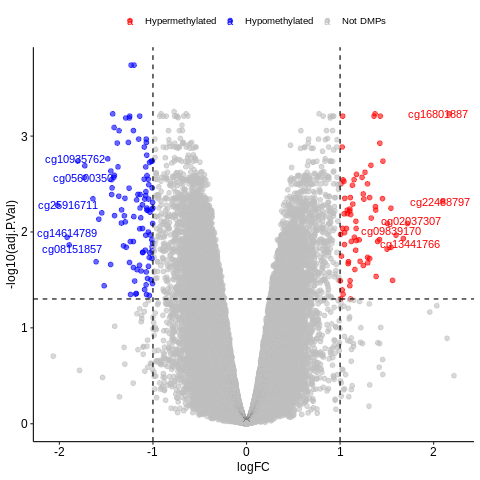

In [78]:
# volcano plot
%%R

ggplot(DMPs, aes(x = logFC, y = negLogP, color = significance)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_vline(xintercept = c(-logFC_cutoff, logFC_cutoff),
             linetype = "dashed") +
  geom_hline(yintercept = -log10(p_cutoff),
             linetype = "dashed") +
  scale_color_manual(values = c("red","blue", "grey")) +
  theme_pubr() +
  geom_text_repel(aes(label = label),
                  max.overlaps = 20) +
  labs(x = "log2FC",
       y = "-log10(adj.P.Val)") +
  theme(legend.title= element_blank())

In [84]:
# Extract beta value
%%R
bVals <- getBeta(mSetSqFlt)

[1] "cg16801887" "cg22488797" "cg02037307" "cg13441766" "cg09839170"


* log2FC 상위 10개 CpG site beta value plot

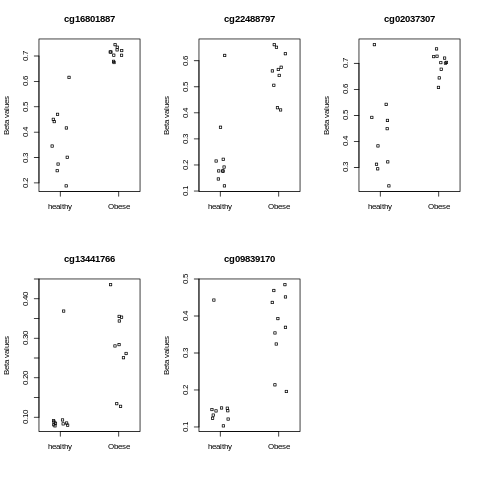

In [92]:
%%R

# 2행 3열 패널
par(mfrow = c(2, 3))

for(i in top_up){
  plotCpg(bVals,
          cpg = i,
          pheno = target$group,
          ylab = "Beta values")
}

* log2FC 하위 10개 CpG site beta value plot

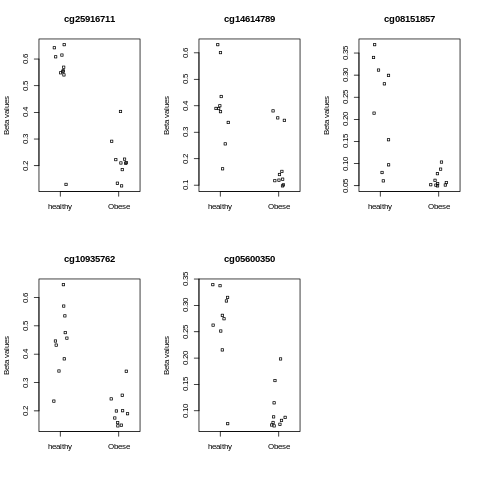

In [93]:
%%R

# 2행 3열 패널
par(mfrow = c(2, 3))

for(i in top_down){
  plotCpg(bVals,
          cpg = i,
          pheno = target$group,
          ylab = "Beta values")
}